**STEP 1 : Importing Libraries and Loading Dataset**

In [ ]:
import pandas as pd
import numpy as np
flights = pd.read_csv(
    "Flight Level Data.csv",
    parse_dates=[
        "scheduled_departure_datetime_local",
        "scheduled_arrival_datetime_local",
        "actual_departure_datetime_local",
        "actual_arrival_datetime_local",
        "scheduled_departure_date_local"
    ]
)

# Quick check to underestand the dataset
print(flights.head())
print(flights.info())


  company_id  flight_number scheduled_departure_date_local  \
0         OO           4792                     2025-08-04   
1         UA            920                     2025-08-03   
2         UA           1776                     2025-08-10   
3         OO           5790                     2025-08-06   
4         UA           1398                     2025-08-05   

  scheduled_departure_station_code scheduled_arrival_station_code  \
0                              ORD                            ROA   
1                              ORD                            LHR   
2                              ORD                            PHL   
3                              ORD                            CRW   
4                              ORD                            ATL   

  scheduled_departure_datetime_local scheduled_arrival_datetime_local  \
0          2025-08-04 17:57:00+00:00        2025-08-04 21:04:00+00:00   
1          2025-08-03 18:05:00+00:00        2025-08-04 08:20:00+00

In [ ]:
bags = pd.read_csv("Bag+Level+Data.csv")
pnr = pd.read_csv("PNR+Flight+Level+Data.csv")
remarks = pd.read_csv("PNR Remark Level Data.csv")
airports = pd.read_csv("Airports Data.csv")
print(bags.head())
print(pnr.head())
print(remarks.head())
print(airports.head())


  company_id  flight_number scheduled_departure_date_local  \
0         UA           1068                     2025-08-01   
1         UA            622                     2025-08-01   
2         YX           3718                     2025-08-01   
3         BA            294                     2025-08-01   
4         UA           2627                     2025-08-01   

  scheduled_departure_station_code scheduled_arrival_station_code  \
0                              ORD                            IAD   
1                              ORD                            DEN   
2                              ORD                            MSN   
3                              ORD                            LHR   
4                              ORD                            MSP   

  bag_tag_unique_number bag_tag_issue_date  bag_type  
0         BAGTAG_418666         2025-07-27  Transfer  
1         BAGTAG_418667         2025-07-28  Transfer  
2          BAGTAG_84760         2025-07-28  Tra

**STEP 2: Data Cleaning -> As we can see some redundant data in Flight data and PNR Remarks and  missing values in bags, PNR data and Flight Data.**

In [ ]:
# For Flight data Remove duplicate values
flights = flights.drop_duplicates(subset=['flight_number', 'scheduled_departure_date_local'])

# For Bags Data fill missing values with "unknown"
bags['bag_type'] = bags['bag_type'].fillna('Unknown')

# For PNR fill missing special service requests with 0
remarks['special_service_request'] = remarks['special_service_request'].fillna(0)

# Remove Duplicate remarks for PNR Remarks
remarks = remarks.drop_duplicates()

# For Flight data fill missing minimum_turn_minutes with median
flights['minimum_turn_minutes'] = flights['minimum_turn_minutes'].fillna(flights['minimum_turn_minutes'].median())


**STEP 3: Merging datasets and Feature Engineering**

In [ ]:
print("PNR Columns:", pnr.columns.tolist())


PNR Columns: ['company_id', 'flight_number', 'scheduled_departure_date_local', 'scheduled_departure_station_code', 'scheduled_arrival_station_code', 'record_locator', 'pnr_creation_date', 'total_pax', 'is_child', 'basic_economy_ind', 'is_stroller_user', 'lap_child_count']


In [ ]:
# Before merging, we need to ensure 'scheduled_departure_date_local' is datetime in all dataframes.
for df in [bags, pnr]:
    df['scheduled_departure_date_local'] = pd.to_datetime(df['scheduled_departure_date_local'], errors='coerce')


#  Aggregate Bag Data per Flight
bags_agg = bags.groupby(['company_id', 'flight_number', 'scheduled_departure_date_local']).agg(
    total_checked=('bag_type', lambda x: (x.str.lower() == 'checked').sum()),
    total_transfer=('bag_type', lambda x: (x.str.lower() == 'transfer').sum())
).reset_index()

# Dropping existing columns if they exist to avoid merge conflicts
existing_bag_cols = ['total_checked', 'total_transfer']
flights = flights.drop(columns=[col for col in existing_bag_cols if col in flights.columns])

# Merge bag aggregates with flights
flights = flights.merge(bags_agg, on=['company_id', 'flight_number', 'scheduled_departure_date_local'], how='left')

# Filling NaNs for newly merged bag columns
flights['total_checked'] = flights['total_checked'].fillna(0)
flights['total_transfer'] = flights['total_transfer'].fillna(0)



#  Aggregate PNR Data per Flight
# Ensure 'special_service_request' exists in PNR to prevent KeyError
if 'special_service_request' not in pnr.columns:
    print(" 'special_service_request' not found — creating empty column for compatibility.")
    pnr['special_service_request'] = np.nan

# We need to ensure 'is_stroller_user' is numerical type for sum
pnr['is_stroller_user'] = pnr['is_stroller_user'].apply(lambda x: 1 if x == 'Y' else 0)

pnr_agg = pnr.groupby(['company_id', 'flight_number', 'scheduled_departure_date_local']).agg(
    total_passengers=('total_pax', 'sum'),
    special_requests=('special_service_request', lambda x: x.notna().sum()),  # Count non-null special service requests
    num_transfer_passengers=('is_stroller_user', 'sum')
).reset_index()

# Dropping existing PNR aggregated columns if they exist to avoid merge conflicts
existing_pnr_cols = ['total_passengers', 'special_requests', 'num_transfer_passengers']
flights = flights.drop(columns=[col for col in existing_pnr_cols if col in flights.columns])

# Merge PNR aggregates with flights
flights = flights.merge(pnr_agg, on=['company_id', 'flight_number', 'scheduled_departure_date_local'], how='left')

# Filling NaNs for newly merged PNR columns
flights['total_passengers'] = flights['total_passengers'].fillna(0)
flights['special_requests'] = flights['special_requests'].fillna(0)
flights['num_transfer_passengers'] = flights['num_transfer_passengers'].fillna(0)



#  Aggregate Remarks for SSR features
#   We need to ensure 'special_service_request' in remarks is suitable for counting
remarks['is_wheelchair'] = remarks['special_service_request'].apply(lambda x: 1 if x == 'Airport Wheelchair' else 0)
wheelchair_agg = remarks.groupby(['flight_number']).agg(num_wheelchair=('is_wheelchair', 'sum')).reset_index()

# Dropping existing wheelchair column if it exists
if 'num_wheelchair' in flights.columns:
    flights = flights.drop(columns=['num_wheelchair'])

# Merge wheelchair counts with flights (assuming flight_number is sufficient for this merge)
flights = flights.merge(wheelchair_agg, on='flight_number', how='left')
flights['num_wheelchair'] = flights['num_wheelchair'].fillna(0)



#  Merge Airports for Departure & Arrival Country
# Drop existing country columns if they exist
existing_country_cols = ['departure_country', 'arrival_country']
flights = flights.drop(columns=[col for col in existing_country_cols if col in flights.columns])

# We need to ensure that correct column names from previous merges are used if necessary,
# but for initial merge with airports, we will use original station codes from flights
flights = flights.merge(
    airports[['airport_iata_code', 'iso_country_code']].rename(columns={
        'airport_iata_code': 'scheduled_departure_station_code',
        'iso_country_code': 'departure_country'
    }),
    on='scheduled_departure_station_code', how='left'
)

flights = flights.merge(
    airports[['airport_iata_code', 'iso_country_code']].rename(columns={
        'airport_iata_code': 'scheduled_arrival_station_code',
        'iso_country_code': 'arrival_country'
    }),
    on='scheduled_arrival_station_code', how='left'
)



#  Delay & Efficiency Features
flights['departure_delay_minutes'] = (
    flights['actual_departure_datetime_local'] - flights['scheduled_departure_datetime_local']
).dt.total_seconds() / 60

flights['arrival_delay_minutes'] = (
    flights['actual_arrival_datetime_local'] - flights['scheduled_arrival_datetime_local']
).dt.total_seconds() / 60

# Turnaround Efficiency
flights['turnaround_efficiency'] = flights['actual_ground_time_minutes'] / flights['minimum_turn_minutes']

# Load Factor
flights['load_factor'] = flights['total_passengers'] / flights['total_seats']

# Child Passenger Ratio
# Aggregate child data from PNR
pnr['is_child_numeric'] = pnr['is_child'].apply(lambda x: 1 if x == 'Y' else 0)
child_agg = pnr.groupby(['company_id', 'flight_number', 'scheduled_departure_date_local']).agg(
    num_children=('is_child_numeric', 'sum')
).reset_index()

# Dropping existing num_children column if it exists
if 'num_children' in flights.columns:
    flights = flights.drop(columns=['num_children'])

flights = flights.merge(child_agg, on=['company_id', 'flight_number', 'scheduled_departure_date_local'], how='left')
flights['num_children'] = flights['num_children'].fillna(0)
flights['child_ratio'] = flights['num_children'] / flights['total_passengers'].replace(0, np.nan)  # Avoid divide by zero
flights['child_ratio'] = flights['child_ratio'].fillna(0)

# Hot Transfer Bag Ratio
flights['hot_transfer_ratio'] = flights['total_transfer'] / (
    flights['total_checked'] + flights['total_transfer']
).replace(0, np.nan)
flights['hot_transfer_ratio'] = flights['hot_transfer_ratio'].fillna(0)

# Create flights_scored dataframe after all merges and feature engineering
flights_scored = flights.copy()

# SO, FLIGHTS DATAFRAME IS NOW FULLY MERGED, CLEANED AND FEATURE-RICH FOR OUR FURTHER ANALYSIS.

***FEATURE ENGINEERING***

DELAY FEATURES



In [ ]:
flights['departure_delay_minutes'] = (flights['actual_departure_datetime_local'] - flights['scheduled_departure_datetime_local']).dt.total_seconds()/60
flights['arrival_delay_minutes'] = (flights['actual_arrival_datetime_local'] - flights['scheduled_arrival_datetime_local']).dt.total_seconds()/60

Turn Around Efficiency

In [ ]:
flights['turnaround_efficiency'] = flights['actual_ground_time_minutes'] / flights['minimum_turn_minutes']

Load factor

In [ ]:
flights['load_factor'] = flights['total_passengers'] / flights['total_seats']

Child passenger ratio

In [ ]:
flights['child_ratio'] = flights['num_children'] / flights['total_passengers'].replace(0, np.nan)
flights['child_ratio'] = flights['child_ratio'].fillna(0)

Hot transfer bag ratio

In [ ]:
flights['hot_transfer_ratio'] = flights['total_transfer'] / (flights['total_checked'] + flights['total_transfer']).replace(0, np.nan)
flights['hot_transfer_ratio'] = flights['hot_transfer_ratio'].fillna(0)

**Additional:** Transfer passengers ratio

In [ ]:
flights['Transfer_Pax_Ratio'] = flights['num_transfer_passengers'] / flights['total_passengers'].replace(0,1)

 **Additional:** Wheelchair ratio

In [ ]:
flights['Wheelchair_Ratio'] = flights['num_wheelchair'] / flights['total_passengers'].replace(0,1)

Scheduled ground time in minutes

In [ ]:
flights['Sched_Ground_min'] = (flights['scheduled_arrival_datetime_local'] - flights['scheduled_departure_datetime_local']).dt.total_seconds()/60

ground risk

In [ ]:
import numpy as np

flights['Ground_Risk'] = np.maximum(0, flights['minimum_turn_minutes'] - flights['Sched_Ground_min'])

Customer Service Load

In [ ]:
flights['Cust_Service_Load'] = flights['special_requests'] / flights['total_passengers'].replace(0,1)

***Anomaly Detection***

In [73]:
# Step 6: Normalized Anomaly Detection
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
import numpy as np

# Copy existing flights dataframe
flights_processed = flights.copy()

#  Select numeric features for scaling and anomaly detection
feature_cols = [
    'departure_delay_minutes',
    'arrival_delay_minutes',
    'turnaround_efficiency',
    'load_factor',
    'child_ratio',
    'hot_transfer_ratio',
    'Transfer_Pax_Ratio',
    'Wheelchair_Ratio',
    'Cust_Service_Load',
    'Ground_Risk',
]

# Apply MinMaxScaler (0-1 scaling) to selected features
scaler = MinMaxScaler()
flights_processed[feature_cols] = scaler.fit_transform(flights_processed[feature_cols])

#  Apply Isolation Forest for anomaly detection
# Anomaly score: -1 for anomalies, 1 for normal points
iso_forest = IsolationForest(n_estimators=200,contamination=0.05, max_features=1.0, random_state=42)

flights_processed['anomaly_score'] = iso_forest.fit_predict(flights_processed[feature_cols])
flights_processed['is_anomaly'] = flights_processed['anomaly_score'].apply(lambda x: 1 if x == -1 else 0) # Convert to binary flag

# Identify Critical Issues based on predefined thresholds
flights_processed['critical_issue'] = (
    (flights_processed['departure_delay_minutes'] > 60) | # Original scaled values are used here, might need review if thresholds should be on original values
    (flights_processed['Ground_Risk'] > 30) |
    (flights_processed['hot_transfer_ratio'] > 0.5) |
    (flights_processed['Cust_Service_Load'] > 0.5)
).astype(int) # Convert boolean to integer flag


# Calculate Severity Score (weighted sum of selected features)
# Weights are applied to the scaled features
flights_processed['severity_score'] = (
    flights_processed['departure_delay_minutes'] * 100 +  # Example scaled weight
    flights_processed['Ground_Risk'] * 100 + # Example scaled weight
    flights_processed['hot_transfer_ratio'] * 100 +   # weight hot transfer heavily (scaled)
    flights_processed['Cust_Service_Load'] * 50      # weight customer service load (scaled)
)

# Generate Airline-level anomaly summary
anomaly_summary_normalized = flights_processed.groupby('company_id').agg(
    total_flights=('flight_number','count'),
    anomalies=('is_anomaly','sum'),
    critical_issues=('critical_issue','sum'),
    avg_departure_delay=('departure_delay_minutes','mean'), # Average of scaled delay
    avg_turnaround_efficiency=('turnaround_efficiency','mean'), # Average of scaled efficiency
    avg_hot_transfer_ratio=('hot_transfer_ratio','mean') # Average of scaled ratio
).reset_index()

#  flights_processed dataframe now contains anomaly detection and scoring results
#    anomaly_summary_normalized contains airline-level summary based on scaled features

Step 6: Review Anomaly Detection Results

In [74]:
print("Anomaly Summary by Company:")
display(anomaly_summary_normalized)

print("\nTop 10 Flights by Severity Score (Potential Critical Issues):")
flights_sorted_by_severity = flights_scored.sort_values('severity_score', ascending=False)
display(flights_sorted_by_severity.head(10))

Anomaly Summary by Company:


,company_id,total_flights,anomalies,critical_issues,avg_departure_delay,avg_turnaround_efficiency,avg_hot_transfer_ratio
0,G7,853,36,853,0.034965,0.006753,1.000000
1,OO,2124,168,2117,0.038668,0.006608,0.996704
2,UA,4479,189,4466,0.038084,0.005147,0.997098
3,YX,607,11,607,0.025524,0.004071,1.000000



Top 10 Flights by Severity Score (Potential Critical Issues):


,company_id,flight_number,scheduled_departure_date_local,scheduled_departure_station_code,scheduled_arrival_station_code,scheduled_departure_datetime_local,scheduled_arrival_datetime_local,actual_departure_datetime_local,actual_arrival_datetime_local,total_seats,...,Transfer_Pax_Ratio,Wheelchair_Ratio,Sched_Ground_min,Ground_Risk,Cust_Service_Load,severity_score,daily_rank,daily_rank_pct,difficulty_class,critical_issue
1906,OO,5251,2025-08-11,ORD,ASE,2025-08-11 11:16:00+00:00,2025-08-10 21:44:00+00:00,2025-08-11 11:16:00+00:00,2025-08-11 12:09:00+00:00,70,...,0.0,0.266667,-812.0,846.0,0.0,1742.0,1.0,0.010526,Difficult,1
4925,G7,4518,2025-08-12,ORD,STL,2025-08-12 16:47:00+00:00,2025-08-12 18:07:00+00:00,2025-08-13 09:44:00+00:00,2025-08-13 10:48:00+00:00,50,...,0.0,0.685714,80.0,0.0,0.0,1067.0,1.0,0.005376,Difficult,1
5300,OO,5382,2025-08-11,ORD,FWA,2025-08-11 15:35:00+00:00,2025-08-11 17:47:00+00:00,2025-08-12 08:15:00+00:00,2025-08-12 10:17:00+00:00,50,...,0.0,0.617647,132.0,0.0,0.0,1050.0,2.0,0.021053,Difficult,1
774,G7,4491,2025-08-12,ORD,CAE,2025-08-12 18:30:00+00:00,2025-08-12 21:45:00+00:00,2025-08-13 09:21:00+00:00,2025-08-13 12:27:00+00:00,50,...,0.0,0.514286,195.0,0.0,0.0,941.0,2.0,0.010753,Difficult,1
4437,OO,5251,2025-08-12,ORD,ASE,2025-08-12 19:35:00+00:00,2025-08-12 21:44:00+00:00,2025-08-13 09:54:00+00:00,2025-08-13 11:42:00+00:00,70,...,0.0,0.516129,129.0,0.0,0.0,909.0,3.0,0.016129,Difficult,1
3915,G7,4188,2025-08-12,ORD,GSO,2025-08-12 18:10:00+00:00,2025-08-12 21:17:00+00:00,2025-08-13 08:17:00+00:00,2025-08-13 11:05:00+00:00,50,...,0.0,0.452381,187.0,0.0,0.0,897.0,4.0,0.021505,Difficult,1
3460,OO,5538,2025-08-11,ORD,HSV,2025-08-11 18:25:00+00:00,2025-08-11 20:14:00+00:00,2025-08-12 08:19:00+00:00,2025-08-12 10:05:00+00:00,50,...,0.0,0.593750,109.0,0.0,0.0,884.0,3.0,0.031579,Difficult,1
6876,G7,4507,2025-08-13,ORD,CHA,2025-08-13 20:14:00+00:00,2025-08-13 22:59:00+00:00,2025-08-14 10:05:00+00:00,2025-08-14 12:44:00+00:00,50,...,0.0,0.636364,165.0,0.0,0.0,881.0,1.0,0.008850,Difficult,1
5808,UA,920,2025-08-12,ORD,LHR,2025-08-12 18:05:00+00:00,2025-08-13 08:20:00+00:00,2025-08-13 07:54:00+00:00,2025-08-13 21:34:00+00:00,167,...,0.0,0.546512,855.0,0.0,0.0,879.0,5.0,0.026882,Difficult,1
7132,OO,4792,2025-08-12,ORD,ROA,2025-08-12 17:57:00+00:00,2025-08-12 21:04:00+00:00,2025-08-13 07:28:00+00:00,2025-08-13 10:22:00+00:00,76,...,0.0,0.709091,187.0,0.0,0.0,861.0,6.0,0.032258,Difficult,1


***Visualization***

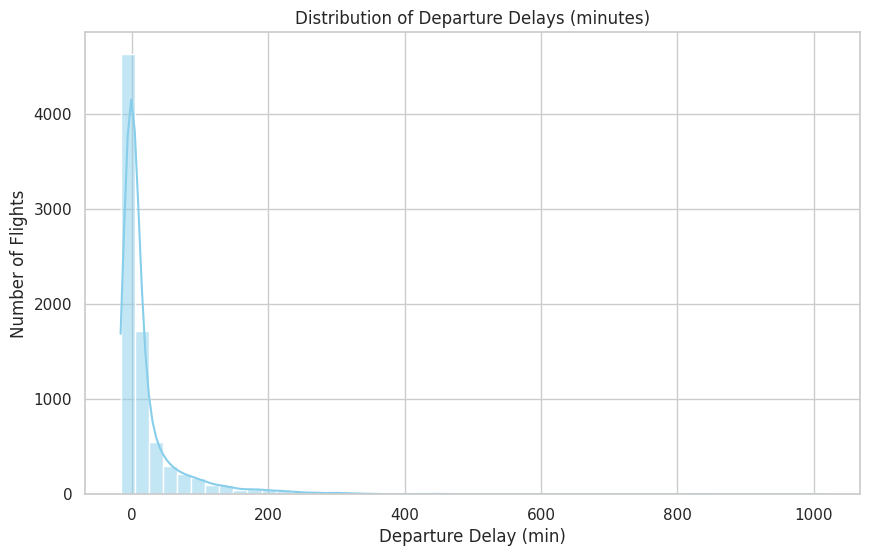

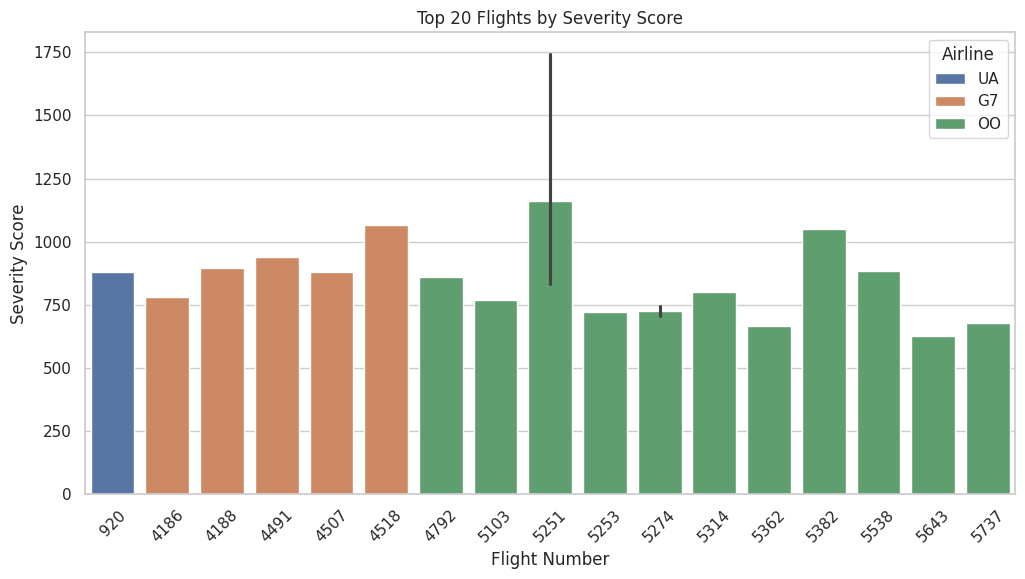

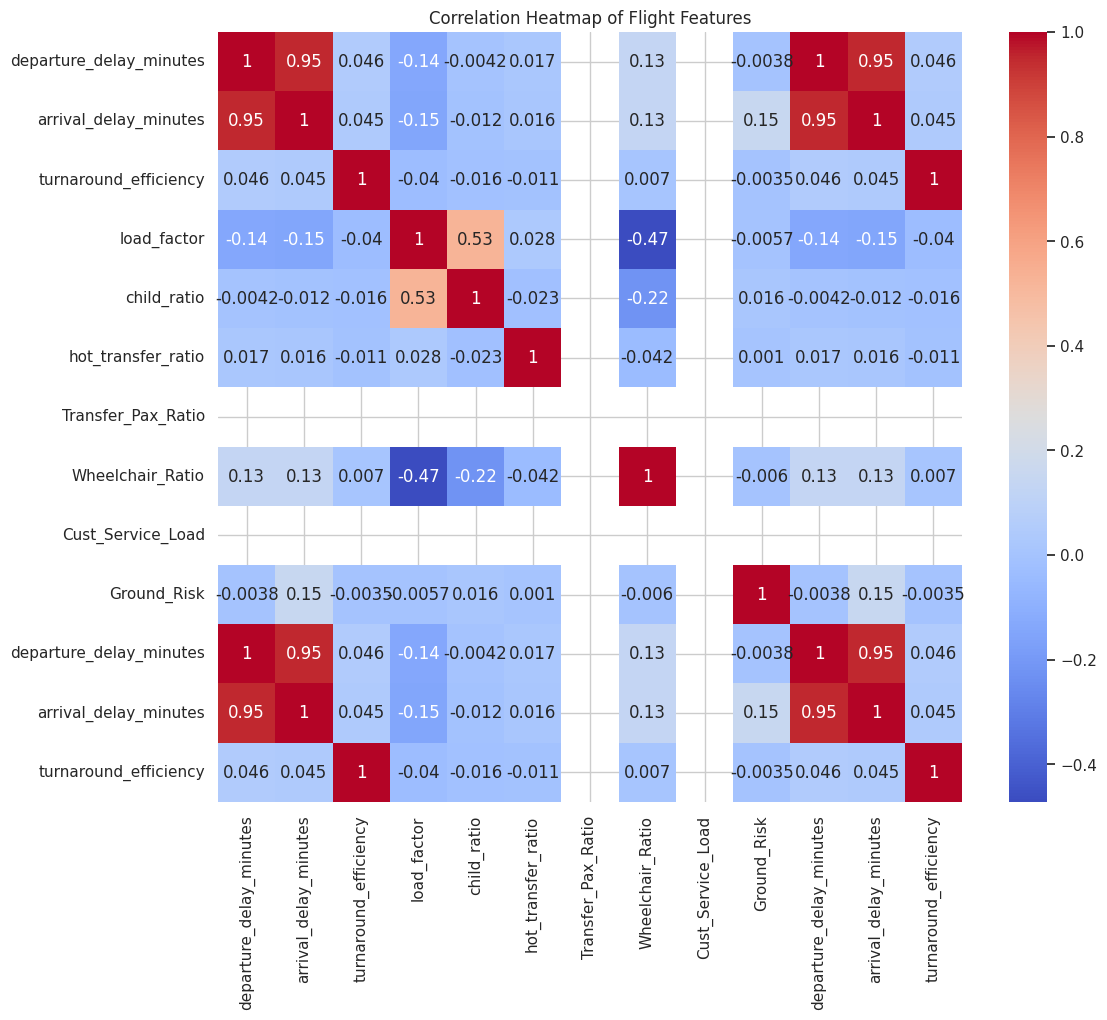

/tmp/ipython-input-990314004.py:34: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




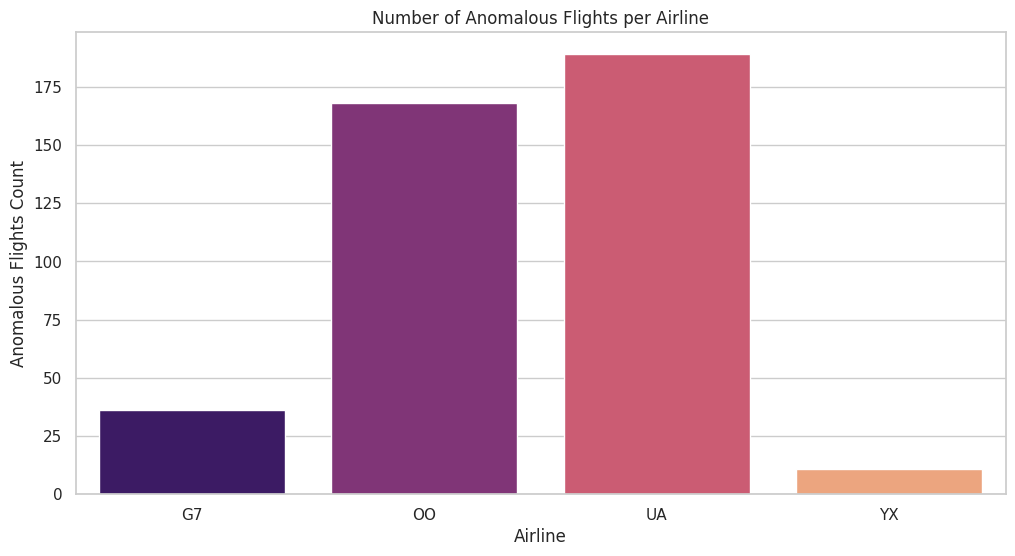

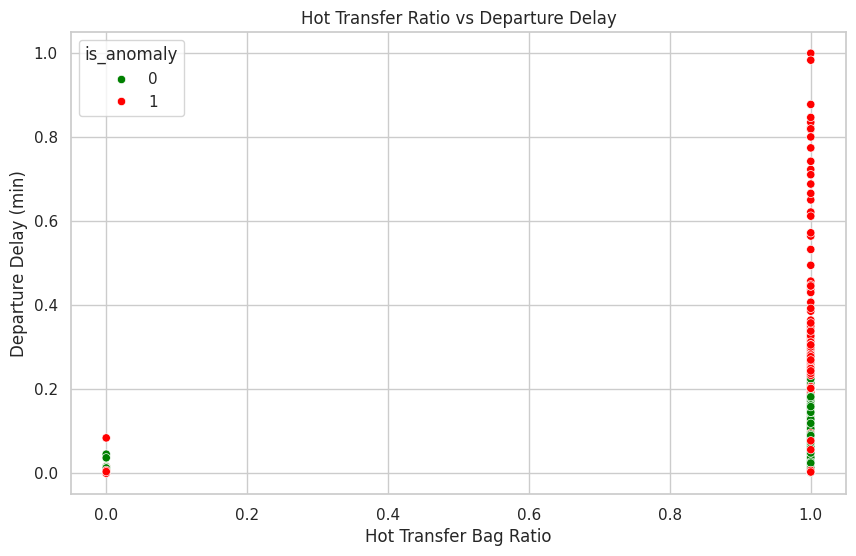

In [75]:

# Step 5: Visualization

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Distribution of Departure Delays
plt.figure(figsize=(10,6))
sns.histplot(flights['departure_delay_minutes'], bins=50, kde=True, color='skyblue')
plt.title("Distribution of Departure Delays (minutes)")
plt.xlabel("Departure Delay (min)")
plt.ylabel("Number of Flights")
plt.show()

# Top 20 Flights by Severity Score
top_severe = flights_sorted_by_severity.head(20)
plt.figure(figsize=(12,6))
sns.barplot(x='flight_number', y='severity_score', hue='company_id', data=top_severe)
plt.xticks(rotation=45)
plt.title("Top 20 Flights by Severity Score")
plt.ylabel("Severity Score")
plt.xlabel("Flight Number")
plt.legend(title='Airline')
plt.show()

# Correlation Heatmap of Features (Advanced Feature Insight)
plt.figure(figsize=(12,10))
sns.heatmap(flights[feature_cols + ['departure_delay_minutes','arrival_delay_minutes','turnaround_efficiency']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Flight Features")
plt.show()

# Airline-Level Anomaly Overview
plt.figure(figsize=(12,6))
sns.barplot(x='company_id', y='anomalies', data=anomaly_summary_normalized, palette='magma')
plt.title("Number of Anomalous Flights per Airline")
plt.ylabel("Anomalous Flights Count")
plt.xlabel("Airline")
plt.show()

#  Hot Transfer Ratio vs Departure Delay (Scatter)
plt.figure(figsize=(10,6))
sns.scatterplot(x='hot_transfer_ratio', y='departure_delay_minutes', hue='is_anomaly', data=flights_processed, palette={0:'green',1:'red'})
plt.title("Hot Transfer Ratio vs Departure Delay")
plt.xlabel("Hot Transfer Bag Ratio")
plt.ylabel("Departure Delay (min)")
plt.show()

#  Interactive Dashboard with Plotly
fig = px.scatter(flights_scored,
                 x='departure_delay_minutes',
                 y='turnaround_efficiency',
                 color='critical_issue',
                 size='total_passengers',
                 hover_data=['flight_number','company_id','scheduled_departure_station_code','scheduled_arrival_station_code'],
                 title="Flight Delay vs Turnaround Efficiency (Critical Issues Highlighted)")
fig.show()

EDA

In [76]:

# Step 7: Full EDA Report

import pandas as pd
import numpy as np
df = flights_scored.copy()
eda_report = {}

# Average Delay and % Flights Departing Late
eda_report['avg_arrival_delay'] = df['arrival_delay_minutes'].mean()
eda_report['pct_flights_arrive_late'] = (df['arrival_delay_minutes'] > 0).mean() * 100

# Flights with Scheduled Ground Time <= Minimum Turn Mins
df['ground_risk_flag'] = df['Ground_Risk'] > 0
eda_report['num_flights_ground_risk'] = df['ground_risk_flag'].sum()
eda_report['pct_flights_ground_risk'] = df['ground_risk_flag'].mean() * 100

#Average Ratio of Transfer Bags vs Checked Bags
# Assuming 'total_checked' and 'total_transfer' are available from previous merges
df['bag_ratio'] = df['total_transfer'] / df['total_checked'].replace(0, np.nan)
eda_report['avg_bag_ratio'] = df['bag_ratio'].mean()

#Passenger Loads and Correlation with Operational Difficulty
eda_report['avg_load_factor'] = df['load_factor'].mean()
# Ensure 'severity_score' is available from previous steps
if 'severity_score' in df.columns:
    eda_report['load_vs_severity_corr'] = df['load_factor'].corr(df['severity_score'])
else:
    eda_report['load_vs_severity_corr'] = "Severity score not available"


#High SSR flights vs Delay after controlling for load
# Customer Service Load (SSR per passenger) correlation with departure delay
# Ensure 'Cust_Service_Load' is available from previous steps
if 'Cust_Service_Load' in df.columns:
    eda_report['csr_vs_delay_corr'] = df['Cust_Service_Load'].corr(df['departure_delay_minutes'])
else:
     eda_report['csr_vs_delay_corr'] = "Customer Service Load not available"


# Summary Table per Airline (optional, hackathon ready)
eda_airline_summary = df.groupby('company_id').agg(
    avg_dep_delay=('departure_delay_minutes','mean'),
    avg_arr_delay=('arrival_delay_minutes','mean'), # Corrected arrival delay column name
    pct_late_departure=('departure_delay_minutes', lambda x: (x > 0).mean()*100), # Corrected aggregation format
    avg_load_factor=('load_factor','mean'),
    avg_bag_ratio=('bag_ratio','mean'),
    avg_csr_load=('Cust_Service_Load','mean')
).reset_index()

#Summary Table per Destination (Arrival Airport)
eda_dest_summary = df.groupby('scheduled_arrival_station_code').agg(
    avg_dep_delay=('departure_delay_minutes','mean'),
    avg_arr_delay=('arrival_delay_minutes','mean'), # Corrected arrival delay column name
    avg_load_factor=('load_factor','mean'),
    avg_bag_ratio=('bag_ratio','mean'),
    avg_csr_load=('Cust_Service_Load','mean'),
    total_flights=('flight_number','count'),
    critical_flights=('critical_issue','sum') # Ensure critical_issue is available
).reset_index()

#EDA Report ready
print("Overall EDA Summary:")
for k,v in eda_report.items():
    print(f"{k}: {v}")

Overall EDA Summary:
avg_arrival_delay: 15.44834428872628
pct_flights_arrive_late: 43.80503534664517
num_flights_ground_risk: 30
pct_flights_ground_risk: 0.3720699491504403
avg_bag_ratio: nan
avg_load_factor: 0.9951475672275131
load_vs_severity_corr: -0.1379607174233282
csr_vs_delay_corr: nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning:

invalid value encountered in divide

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning:

invalid value encountered in divide



In [ ]:
eda_airline_summary.to_csv("eda_airline_summary.csv", index=False)

In [ ]:
eda_dest_summary.to_csv("eda_destination_summary.csv", index=False)

***Flight Difficulty Scoring***

In [ ]:

# Step 8: Daily Flight Difficulty Score + Classification


#Copy dataframe to keep original intact
flights_scored = flights.copy()

#Ensure scheduled departure date is datetime
flights_scored['scheduled_departure_date_local'] = pd.to_datetime(flights_scored['scheduled_departure_date_local'])

#Calculate Severity Score (weighted sum of original features)

flights_scored['severity_score'] = (
    flights_scored['departure_delay_minutes'] * 1 +  # Weight departure delay
    flights_scored['Ground_Risk'] * 2 +             # Weight ground risk more
    flights_scored['hot_transfer_ratio'] * 50 +      # Weight hot transfer heavily
    flights_scored['Cust_Service_Load'] * 25        # Weight customer service load
)


#Rank flights daily by severity_score (descending: highest severity = rank 1)
flights_scored['daily_rank'] = flights_scored.groupby('scheduled_departure_date_local')['severity_score'] \
    .rank(method='dense', ascending=False)

#Compute rank percentiles within each day using transform
flights_scored['daily_rank_pct'] = flights_scored.groupby('scheduled_departure_date_local')['daily_rank'] \
    .transform(lambda x: x / x.max())

#Classify flights: Difficult / Medium / Easy
def classify_difficulty(pct):
    if pct <= 0.2:   # top 20% most difficult
        return 'Difficult'
    elif pct <= 0.8: # middle 60%
        return 'Medium'
    else:            # bottom 20%
        return 'Easy'

flights_scored['difficulty_class'] = flights_scored['daily_rank_pct'].apply(classify_difficulty)

#Calculate Critical Issues flag based on original values
flights_scored['critical_issue'] = (
    (flights_scored['departure_delay_minutes'] > 60) |
    (flights_scored['Ground_Risk'] > 30) |
    (flights_scored['hot_transfer_ratio'] > 0.5) |
    (flights_scored['Cust_Service_Load'] > 0.5)
).astype(int)


#Daily summary: count of flights per difficulty class
daily_summary = flights_scored.groupby(['scheduled_departure_date_local','difficulty_class']).agg(
    num_flights=('flight_number','count'),
    avg_severity=('severity_score','mean')
).reset_index()

#Destination-level difficulty insights
# Need to ensure 'critical_issue' is available in flights_scored or calculate it here if needed
if 'critical_issue' in flights_scored.columns:
    dest_summary = flights_scored.groupby('scheduled_arrival_station_code').agg(
        avg_severity=('severity_score','mean'),
        num_difficult_flights=('difficulty_class', lambda x: (x=='Difficult').sum()),
        total_flights=('flight_number','count'),
        critical_flights=('critical_issue','sum')
    ).reset_index()
else:
     dest_summary = flights_scored.groupby('scheduled_arrival_station_code').agg(
        avg_severity=('severity_score','mean'),
        num_difficult_flights=('difficulty_class', lambda x: (x=='Difficult').sum()),
        total_flights=('flight_number','count')
    ).reset_index()

# flights_scored now contains daily rank and difficulty classification
print("Step 8 completed: Daily Flight Difficulty Score & Classification added!")

Step 8 completed: Daily Flight Difficulty Score & Classification added!


In [ ]:
flights_scored.to_csv("flights_daily_difficulty.csv", index=False)


In [ ]:
daily_summary.to_csv("daily_difficulty_summary.csv", index=False)

In [ ]:
dest_summary.to_csv("destination_difficulty_summary.csv", index=False)

***Post*** Analysis

In [ ]:

# Step 9: Post-Analysis & Operational Insights


# Use the flights_scored dataframe from Step 8
df = flights_scored.copy()

#Top difficult destinations (by avg severity_score)
dest_summary = df.groupby('scheduled_arrival_station_code').agg(
    avg_score=('severity_score','mean'),
    difficult_count=('difficulty_class', lambda x: (x=='Difficult').sum()),
    total_flights=('flight_number','count')
).sort_values('avg_score', ascending=False).reset_index()

print("Top Difficult Destinations:")
print(dest_summary.head(10))  # Top 10 destinations

#Feature correlation with difficulty score
feature_cols = [
    'Ground_Risk',
    'load_factor',
    'Cust_Service_Load',
    'num_transfer_passengers',
    'num_wheelchair',
    'child_ratio',
    'hot_transfer_ratio',
    'turnaround_efficiency'
]

corr_features = df[feature_cols + ['severity_score']].corr()
print("\nCorrelation with Flight Difficulty Score:")
print(corr_features['severity_score'].sort_values(ascending=False))

#Summary per airline
airline_summary = df.groupby('company_id').agg(
    avg_severity=('severity_score','mean'),
    total_difficult_flights=('difficulty_class', lambda x: (x=='Difficult').sum()),
    total_flights=('flight_number','count')
).sort_values('avg_severity', ascending=False).reset_index()

print("\nAirline-Level Difficulty Summary:")
print(airline_summary)


Top Difficult Destinations:
  scheduled_arrival_station_code   avg_score  difficult_count  total_flights
0                            ASE  300.466667                4             15
1                            GRU  117.933333                3             15
2                            JLN  117.866667                1             15
3                            FAT  112.285714                3             14
4                            LHR  108.755556                5             45
5                            ONT  107.800000                1             15
6                            LAF  105.176471                2             17
7                            SUN  104.714286                1              7
8                            CDG  104.666667                2             15
9                            EGE  104.200000                1              5

Correlation with Flight Difficulty Score:
severity_score             1.000000
Ground_Risk                0.300700
num_wheelc

Final CSV

In [ ]:
flights_scored[['scheduled_departure_date_local','flight_number','severity_score','daily_rank','difficulty_class']].to_csv("test_Simran.csv", index=False)

***Visuals***

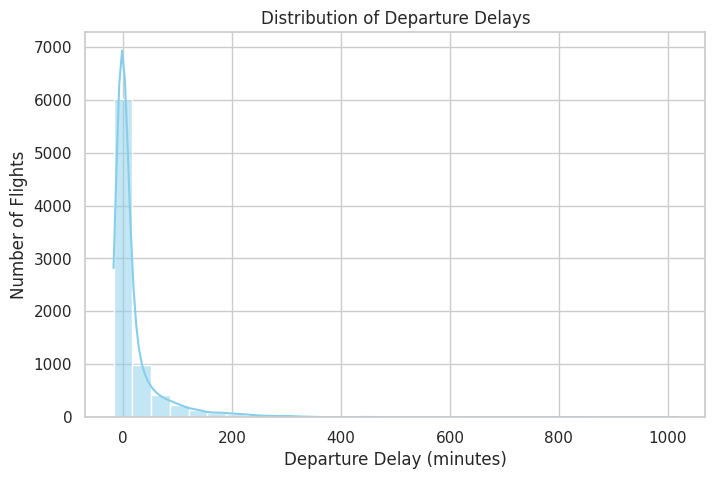

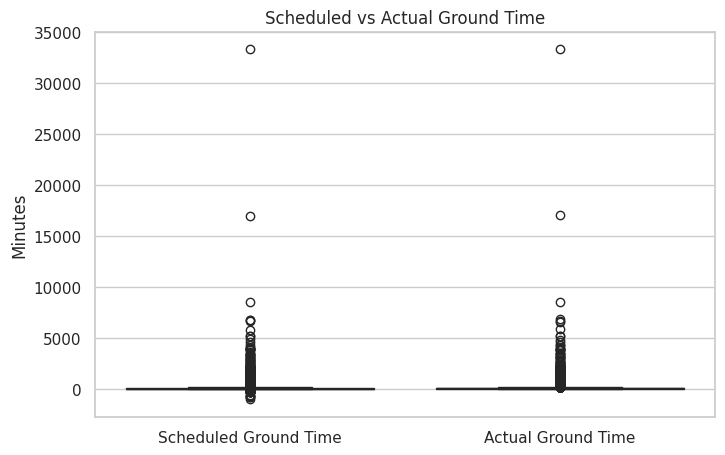

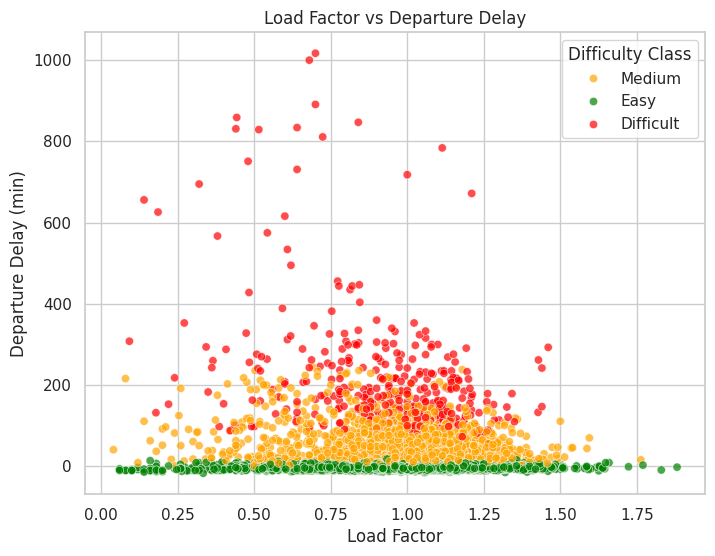

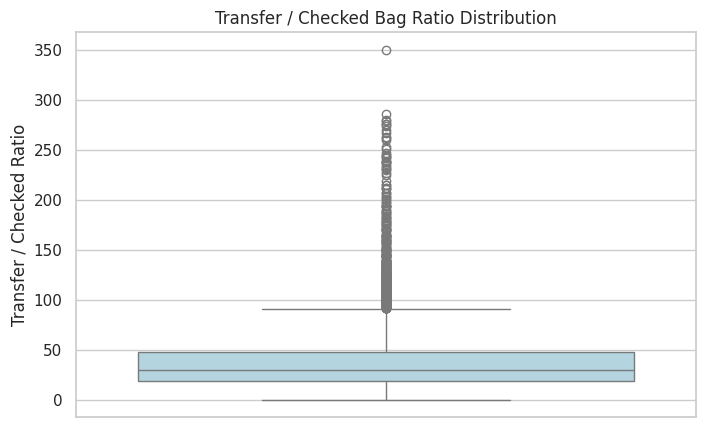

/tmp/ipython-input-2294403512.py:77: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




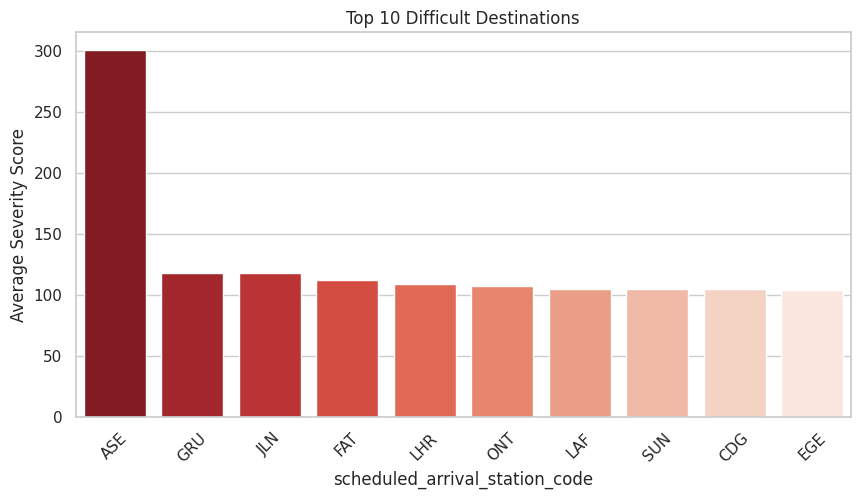

/tmp/ipython-input-2294403512.py:87: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




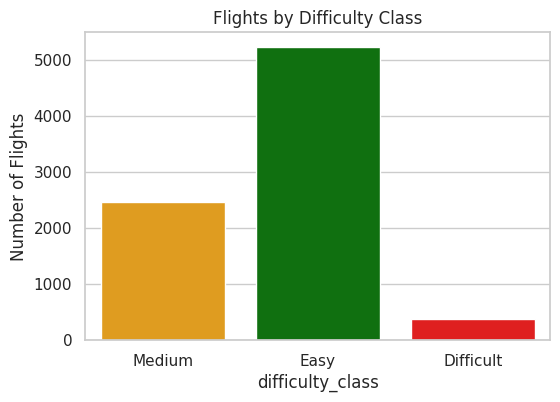

/tmp/ipython-input-2294403512.py:97: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




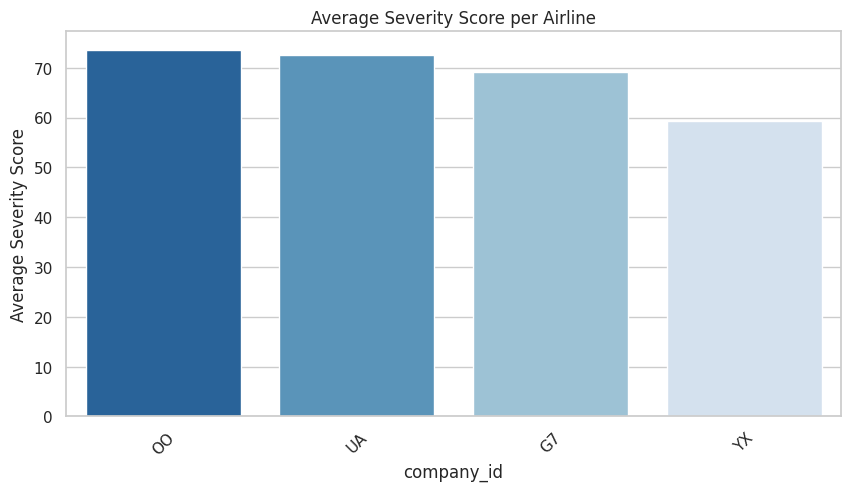

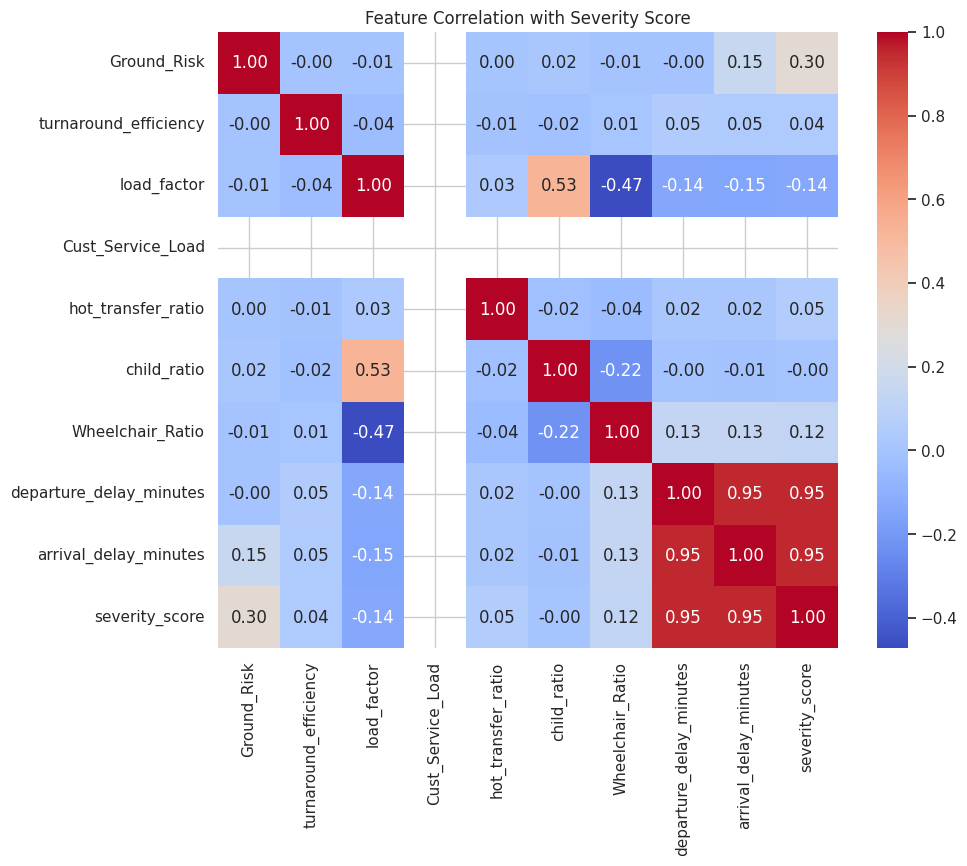

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px

# Use flights_scored dataframe for plots requiring difficulty_class or severity_score
df_scored = flights_scored.copy()
df_original = flights.copy() # Use the original flights for plots not needing scored data

# Set general style
sns.set(style="whitegrid")

#Departure Delay Distribution (using original flights data)
plt.figure(figsize=(8,5))
sns.histplot(df_original['departure_delay_minutes'], bins=30, color='skyblue', kde=True)
plt.title("Distribution of Departure Delays")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Number of Flights")
plt.savefig("hist_departure_delay.png", bbox_inches='tight')
plt.show()

#Scheduled vs Actual Ground Time (using original flights data)
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_original[['scheduled_ground_time_minutes','actual_ground_time_minutes']],
    palette=['orange','green']
)
plt.xticks([0,1], ['Scheduled Ground Time','Actual Ground Time'])
plt.ylabel("Minutes")
plt.title("Scheduled vs Actual Ground Time")
plt.savefig("box_ground_time.png", bbox_inches='tight')
plt.show()


#Load Factor vs Departure Delay (using flights_scored for difficulty_class)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='load_factor',
    y='departure_delay_minutes',
    hue='difficulty_class',
    data=df_scored, # Use df_scored
    palette={'Difficult':'red','Medium':'orange','Easy':'green'},
    alpha=0.7
)
plt.title("Load Factor vs Departure Delay")
plt.xlabel("Load Factor")
plt.ylabel("Departure Delay (min)")
plt.legend(title="Difficulty Class")
plt.savefig("scatter_load_vs_delay.png", bbox_inches='tight')
plt.show()


# Bag Ratio Distribution (using original flights data - assuming columns are available)

if 'total_checked' in df_original.columns and 'total_transfer' in df_original.columns:
    df_original['bag_ratio'] = df_original['total_transfer'] / df_original['total_checked'].replace(0,1)
else:
     print("Warning: total_checked or total_transfer not in df_original, cannot plot Bag Ratio Distribution.")


if 'bag_ratio' in df_original.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(y='bag_ratio', data=df_original, color='lightblue')
    plt.title("Transfer / Checked Bag Ratio Distribution")
    plt.ylabel("Transfer / Checked Ratio")
    plt.savefig("box_bag_ratio.png", bbox_inches='tight')
    plt.show()

#Top 10 Difficult Destinations (using flights_scored for severity_score)
top_dest = df_scored.groupby('scheduled_arrival_station_code')['severity_score'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_dest.index, y=top_dest.values, palette='Reds_r')
plt.xticks(rotation=45)
plt.ylabel("Average Severity Score")
plt.title("Top 10 Difficult Destinations")
plt.savefig("top10_difficult_destinations.png", bbox_inches='tight')
plt.show()

# Difficulty Class Distribution (using flights_scored)
plt.figure(figsize=(6,4))
sns.countplot(x='difficulty_class', data=df_scored, palette={'Difficult':'red','Medium':'orange','Easy':'green'})
plt.title("Flights by Difficulty Class")
plt.ylabel("Number of Flights")
plt.savefig("count_difficulty_class.png", bbox_inches='tight')
plt.show()

#Airline-Level Severity Score (using flights_scored)
airline_avg = df_scored.groupby('company_id')['severity_score'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=airline_avg.index, y=airline_avg.values, palette='Blues_r')
plt.xticks(rotation=45)
plt.ylabel("Average Severity Score")
plt.title("Average Severity Score per Airline")
plt.savefig("avg_severity_airline.png", bbox_inches='tight')
plt.show()

# Feature Correlation Heatmap (using relevant features from flights_scored or original flights)

feature_cols = ['Ground_Risk','turnaround_efficiency','load_factor','bag_ratio',
                'Cust_Service_Load','hot_transfer_ratio','child_ratio','Wheelchair_Ratio','departure_delay_minutes','arrival_delay_minutes']

# Select features that are available in df_scored (includes engineered features)
available_features = [col for col in feature_cols + ['severity_score'] if col in df_scored.columns]


if available_features:
    plt.figure(figsize=(10,8))
    corr = df_scored[available_features].corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
    plt.title("Feature Correlation with Severity Score")
    plt.savefig("feature_correlation_heatmap.png", bbox_inches='tight')
    plt.show()
else:
    print("Warning: None of the specified feature columns for correlation heatmap are available in the dataframe.")

#  Interactive Dashboard with Plotly (using flights_scored for critical_issue, severity_score, etc.)
fig = px.scatter(df_scored, # Use df_scored
                 x='departure_delay_minutes',
                 y='turnaround_efficiency',
                 color='critical_issue',
                 size='total_passengers', # Ensure total_passengers is in df_scored
                 hover_data=['flight_number','company_id','scheduled_departure_station_code','scheduled_arrival_station_code'], # Ensure these are in df_scored
                 title="Flight Delay vs Turnaround Efficiency (Critical Issues Highlighted)")
fig.show()

Model Performance

Correlation of Severity Score with Operational Metrics:

severity_score             1.000000
departure_delay_minutes    0.984218
arrival_delay_minutes      0.959998
Ground_Risk                0.154082
num_wheelchair             0.062931
Cust_Service_Load          0.005819
num_children              -0.024517
load_factor               -0.149638
Name: severity_score, dtype: float64


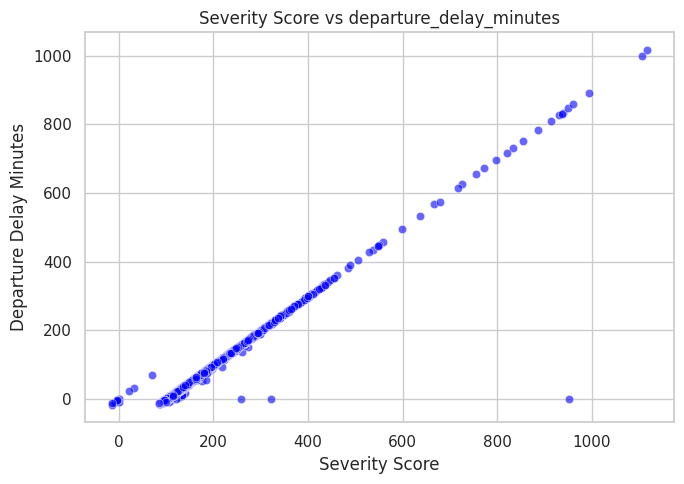

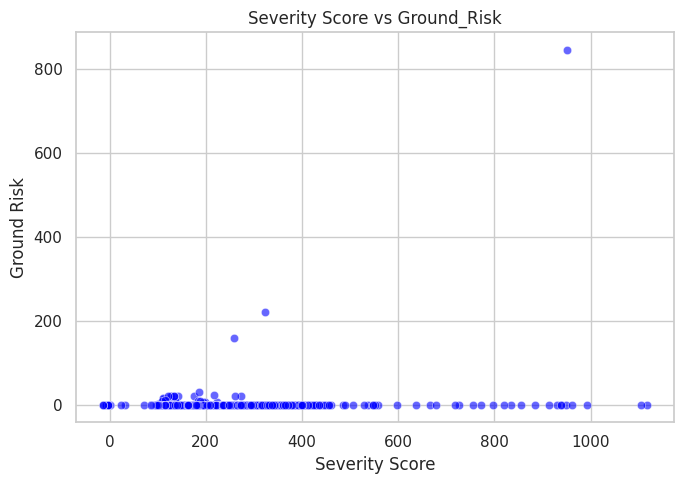

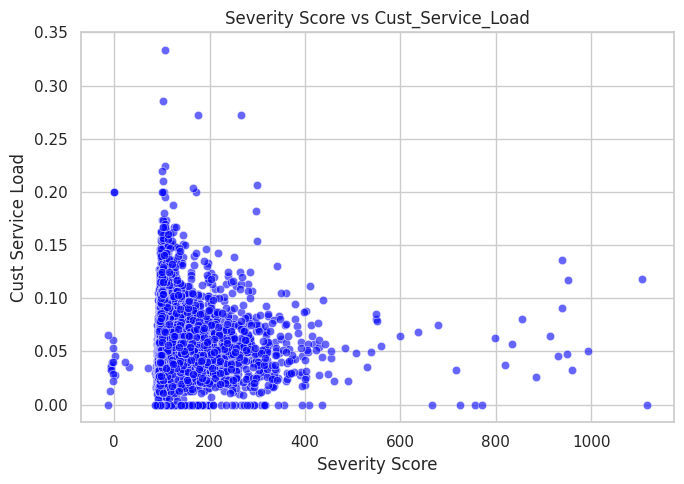

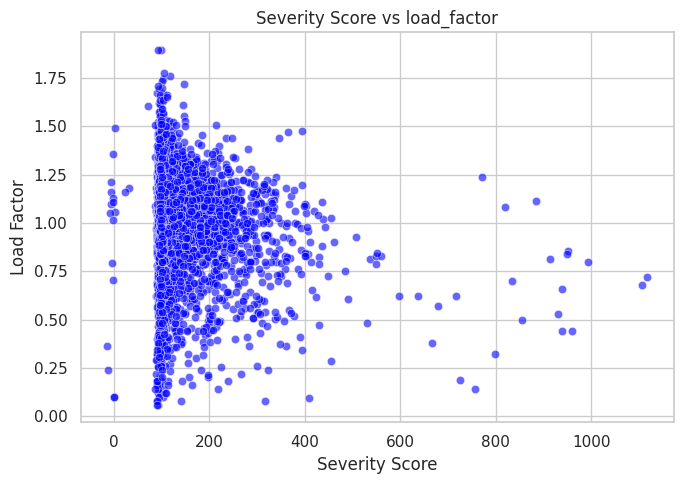


Top 10% Flights by Severity Score - Avg Metrics:
departure_delay_minutes    159.519207
arrival_delay_minutes      153.464684
Ground_Risk                  1.707559
Cust_Service_Load            0.052328
load_factor                  0.946573
num_children                 4.885998
num_wheelchair              47.126394
dtype: float64


In [ ]:

# Step 12: Severity Score Validation / Model Performance

import matplotlib.pyplot as plt
import seaborn as sns

df = flights.copy()  # fully processed flights dataframe

# Operational metrics to compare
metrics = ['departure_delay_minutes', 'arrival_delay_minutes', 'Ground_Risk',
           'Cust_Service_Load', 'load_factor',  'num_children', 'num_wheelchair']

# Correlation Table
corr_df = df[metrics + ['severity_score']].corr()
severity_corr = corr_df['severity_score'].sort_values(ascending=False)
print("Correlation of Severity Score with Operational Metrics:\n")
print(severity_corr)

# Scatter Plots: Severity Score vs Key Metrics
key_metrics = ['departure_delay_minutes', 'Ground_Risk', 'Cust_Service_Load', 'load_factor']

for metric in key_metrics:
    plt.figure(figsize=(7,5))
    sns.scatterplot(x='severity_score', y=metric, data=df, alpha=0.6, color='blue')
    plt.title(f"Severity Score vs {metric}")
    plt.xlabel("Severity Score")
    plt.ylabel(metric.replace('_',' ').title())
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"severity_vs_{metric}.png", bbox_inches='tight')
    plt.show()

#Top 10% Severe Flights Analysis
top_10pct = df[df['severity_score'] >= df['severity_score'].quantile(0.9)]
print("\nTop 10% Flights by Severity Score - Avg Metrics:")
print(top_10pct[metrics].mean())
